

# **EDA - Exploratory Data Analysis**



| Explanatory variable | Variable type | Description |
| :--- | :--- | :--- |
| **Car age** | Numeric | Number of years since the vehicle's production year. |
| **Engine displacement** | Numeric | Engine displacement volume, expressed in cubic centimeters (cm3). |
| **Mileage** | Numeric | Total distance traveled by the vehicle, in kilometers. |
| **Engine power** | Numeric | Power of the engine, expressed in horsepower (HP). |
| **Equipment count** | Numeric | Number of additional equipment features counted in the vehicle. |
| **Number of doors** | Numeric | Total number of doors on the vehicle body. |
| **Brand** | Categorical | Vehicle manufacturer, indicating its prestige and market segment. |
| **Gearbox** | Categorical | Type of transmission used in the car (e.g. manual, automatic). |
| **Fuel type** | Categorical | Type of fuel powering the engine (e.g. petrol, diesel, LPG, hybrid, electric). |
| **Drivetrain** | Categorical | Type of driven axle (e.g. front-wheel, rear-wheel, 4x4). |
| **Voivodeship** | Categorical | Region of Poland where the vehicle is registered or sold. |
| **Body type** | Categorical | Vehicle body style (e.g. sedan, estate, SUV, hatchback). |
| **Color** | Categorical | Color of the vehicle's paint. |
| **Damaged** | Categorical | Whether the vehicle has body or mechanical damage (Yes/No). |
| **Seller type** | Categorical | Professional or private seller. |
| **Leather upholstery** | Categorical | Whether the seats are finished with leather material (Yes/No). |
| **Imported** | Categorical | Whether the vehicle comes from a Polish dealership (Yes/No). |
| **Authorized service** | Categorical | Whether the car was regularly serviced at an Authorized Service Station (Yes/No). |
| **Panoramic roof** | Categorical | Whether the car has a glass roof above the passenger space (Yes/No). |
| **LED headlights** | Categorical | Whether the front headlights use LED technology (Yes/No). |
| **First owner** | Categorical | Whether the vehicle has had only one owner since new (Yes/No). |
| **Automatic air conditioning** | Categorical | Whether the car has electronically controlled air conditioning (Yes/No). |
| **Rear camera** | Categorical | Whether the car has a video system that assists with reversing (Yes/No). |
| **Heated seats** | Categorical | Whether the front or rear seats can be electrically heated (Yes/No). |
| **Cruise control** | Categorical | Whether the car has a system for automatic speed control (Yes/No). |
| **Adaptive cruise control** | Categorical | Whether the car has an advanced cruise control that keeps a safe distance (Yes/No). |
| **Traffic sign recognition** | Categorical | Whether the car has a camera-based system for recognizing road signs (Yes/No). |
| **Wireless charger** | Categorical | Whether the car has a wireless phone charging pad in the cabin (Yes/No). |
| **LED rear lights** | Categorical | Whether the rear lights use LED technology (Yes/No). |
| **Android Auto** | Categorical | Whether the car supports connecting a smartphone to the infotainment screen (Yes/No). |

## **Initial Exploration**



In [1]:
import pandas as pd
import numpy as np
import scipy as sp
import sklearn
from pathlib import Path

pd.options.display.float_format = '{:.3f}'.format

In [2]:

# Path.cwd() returns the 'notebooks' folder. .parent moves one level up to the project root.
BASE_DIR = Path.cwd().parent

# Path to the file in the data folder
data_file_path = BASE_DIR / "data" / "cleaned_listings.csv"

# Load the data
vehicle_listings = pd.read_csv(data_file_path)

#### **Displaying basic information about our dataset to see the data types of each column**

In [3]:
vehicle_listings.info()

<class 'pandas.DataFrame'>
RangeIndex: 4874 entries, 0 to 4873
Data columns (total 30 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   cena                       4874 non-null   float64
 1   marka                      4874 non-null   str    
 2   wiek_auta                  4874 non-null   int64  
 3   pojemnosc_silnika          4861 non-null   float64
 4   przebieg                   4874 non-null   float64
 5   moc_silnika                4841 non-null   float64
 6   skrzynia_biegow            4874 non-null   str    
 7   paliwo                     4874 non-null   str    
 8   naped                      4532 non-null   str    
 9   wojewodztwo                4874 non-null   str    
 10  nadwozie                   4874 non-null   str    
 11  kolor                      4874 non-null   str    
 12  ilosc_wyposazenia          4874 non-null   int64  
 13  liczba_drzwi               4636 non-null   float64
 14  typ

As we can see, the dataset contains 4,874 records, and each one has 30 columns that serve as explanatory variables. The target variable is the price. We can also see that some columns have missing values, which will be handled in a later step.

##### **Splitting variables into numeric, base categorical, and equipment categorical columns**

In [4]:
numeric_columns = vehicle_listings.select_dtypes(include=[np.number]).columns.drop(['cena', 'liczba_drzwi'])
base_categorical_columns = pd.Index(['marka', 'skrzynia_biegow', 'paliwo', 'naped', 'wojewodztwo', 'nadwozie', 'kolor', 'typ_sprzedawcy', 'liczba_drzwi'])
equipment_categorical_columns = vehicle_listings.select_dtypes(include=['string']).columns.drop(base_categorical_columns, errors="ignore")
vehicle_listings['liczba_drzwi'] = vehicle_listings['liczba_drzwi'].astype(str)

print("Numeric:", numeric_columns.tolist())
print("Base categorical:", base_categorical_columns.tolist())
print("Equipment categorical:", equipment_categorical_columns.tolist())


Numeric: ['wiek_auta', 'pojemnosc_silnika', 'przebieg', 'moc_silnika', 'ilosc_wyposazenia']
Base categorical: ['marka', 'skrzynia_biegow', 'paliwo', 'naped', 'wojewodztwo', 'nadwozie', 'kolor', 'typ_sprzedawcy', 'liczba_drzwi']
Equipment categorical: ['skorzana_tapicerka', 'importowany', 'serwis_aso', 'dach_panoramiczny', 'swiatla_led', 'pierwszy_wlasciciel', 'klimatyzacja_automatyczna', 'kamera_cofania', 'podgrzewane_fotele', 'tempomat', 'aktywny_tempomat', 'czytanie_znakow', 'ladowarka_indukcyjna', 'swiatla_tylne_led', 'android_auto']


This grouping will make it easier to process the variables in later steps (e.g. during visualization).

#### **Basic descriptive statistics for each group of variables**

In [5]:
vehicle_listings[numeric_columns].describe(include='all')

,wiek_auta,pojemnosc_silnika,przebieg,moc_silnika,ilosc_wyposazenia
count,4874.000,4861.000,4874.000,4841.000,4874.000
mean,10.090,1912.686,144029.135,168.287,40.178
std,6.968,739.056,95749.357,75.378,27.015
min,0.000,400.000,5000.000,1.000,0.000
25%,4.000,1498.000,65000.000,120.000,22.000
50%,8.000,1840.000,136000.000,150.000,38.000
75%,16.000,1997.000,207000.000,194.000,57.000
max,25.000,6417.000,1241870.000,999.000,147.000


In [6]:
vehicle_listings[base_categorical_columns].describe(include='all')

,marka,skrzynia_biegow,paliwo,naped,wojewodztwo,nadwozie,kolor,typ_sprzedawcy,liczba_drzwi
count,4874,4874,4874,4532,4874,4874,4874,4874,4636
unique,60,2,5,5,16,9,18,2,4
top,BMW,Automatyczna,Benzyna,Na przednie koła,mazowieckie,SUV,Czarny,PRIVATE,5.0
freq,453,2636,2563,2946,1051,1516,1286,2543,3711


In [7]:
vehicle_listings[equipment_categorical_columns].describe(include='all')

,skorzana_tapicerka,importowany,serwis_aso,dach_panoramiczny,swiatla_led,pierwszy_wlasciciel,klimatyzacja_automatyczna,kamera_cofania,podgrzewane_fotele,tempomat,aktywny_tempomat,czytanie_znakow,ladowarka_indukcyjna,swiatla_tylne_led,android_auto
count,4874,4874,4874,4874,4874,4874,4874,4874,4874,4874,4874,4874,4874,4874,4874
unique,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2
top,Tak,Tak,Tak,Nie,Nie,Nie,Tak,Nie,Nie,Tak,Nie,Nie,Nie,Nie,Nie
freq,3558,4081,2521,4324,2816,3199,3368,2914,2562,3305,4014,3570,4219,3113,3094


## **Identifying and Handling Missing Data**

Let's check the number of missing values in each column.

In [8]:
vehicle_listings.isna().sum()

cena                           0
marka                          0
wiek_auta                      0
pojemnosc_silnika             13
przebieg                       0
moc_silnika                   33
skrzynia_biegow                0
paliwo                         0
naped                        342
wojewodztwo                    0
nadwozie                       0
kolor                          0
ilosc_wyposazenia              0
liczba_drzwi                 238
typ_sprzedawcy                 0
skorzana_tapicerka             0
importowany                    0
serwis_aso                     0
dach_panoramiczny              0
swiatla_led                    0
pierwszy_wlasciciel            0
klimatyzacja_automatyczna      0
kamera_cofania                 0
podgrzewane_fotele             0
tempomat                       0
aktywny_tempomat               0
czytanie_znakow                0
ladowarka_indukcyjna           0
swiatla_tylne_led              0
android_auto                   0
dtype: int

We can see the number of missing values in these columns. We will analyze each of them.

### **Engine Displacement Column**

In [9]:
vehicle_listings[vehicle_listings["pojemnosc_silnika"].isna()]

,cena,marka,wiek_auta,pojemnosc_silnika,przebieg,moc_silnika,skrzynia_biegow,paliwo,naped,wojewodztwo,...,pierwszy_wlasciciel,klimatyzacja_automatyczna,kamera_cofania,podgrzewane_fotele,tempomat,aktywny_tempomat,czytanie_znakow,ladowarka_indukcyjna,swiatla_tylne_led,android_auto
40,14000.000,Seat,17,NaN,15000.000,125.000,Manualna,Benzyna,NaN,malopolskie,...,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie
186,59900.000,Hyundai,8,NaN,146000.000,177.000,Manualna,Benzyna,Na przednie koła,warminsko-mazurskie,...,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie
247,19300.000,Skoda,11,NaN,148000.000,NaN,Manualna,Diesel,NaN,swietokrzyskie,...,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie
961,36000.000,Kia,8,NaN,270000.000,NaN,Automatyczna,Diesel,NaN,lubelskie,...,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie
1310,10000.000,Audi,17,NaN,214865.000,NaN,Manualna,Benzyna,Na przednie koła,malopolskie,...,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie
1815,185000.000,Audi,3,NaN,50000.000,NaN,Automatyczna,Benzyna,NaN,lodzkie,...,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie
3189,11000.000,Audi,21,NaN,179452.000,260.000,Automatyczna,Benzyna,Na przednie koła,opolskie,...,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie
3200,13000.000,BMW,22,NaN,200000.000,NaN,Automatyczna,Diesel,NaN,dolnoslaskie,...,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie
3236,15500.000,BMW,23,NaN,345000.000,193.000,Automatyczna,Diesel,Na tylne koła,swietokrzyskie,...,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie
3238,49500.000,Toyota,25,NaN,94000.000,NaN,Automatyczna,Benzyna,NaN,pomorskie,...,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie


We identified 13 observations with missing data. These will be filled in using the median value for the vehicle's brand.

In [10]:
vehicle_listings['pojemnosc_silnika'] = vehicle_listings['pojemnosc_silnika'].fillna(vehicle_listings.groupby('marka')['pojemnosc_silnika'].transform('median'))
print(f"Number of missing values in 'pojemnosc_silnika': {vehicle_listings[vehicle_listings['pojemnosc_silnika'].isna()].shape[0]}")

Number of missing values in 'pojemnosc_silnika': 0


### **Engine Power Column**

In [11]:
vehicle_listings[vehicle_listings["moc_silnika"].isna()]

,cena,marka,wiek_auta,pojemnosc_silnika,przebieg,moc_silnika,skrzynia_biegow,paliwo,naped,wojewodztwo,...,pierwszy_wlasciciel,klimatyzacja_automatyczna,kamera_cofania,podgrzewane_fotele,tempomat,aktywny_tempomat,czytanie_znakow,ladowarka_indukcyjna,swiatla_tylne_led,android_auto
12,11500.000,Toyota,20,1298.000,175000.000,NaN,Manualna,Benzyna,NaN,lodzkie,...,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie
24,13500.000,Seat,17,1600.000,227450.000,NaN,Manualna,Benzyna,Na przednie koła,kujawsko-pomorskie,...,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie
26,11500.000,Peugeot,21,1600.000,208000.000,NaN,Manualna,Benzyna,Na przednie koła,mazowieckie,...,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie
34,14900.000,Mitsubishi,18,2400.000,300000.000,NaN,Manualna,Benzyna+LPG,Na przednie koła,slaskie,...,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie
35,11900.000,BMW,20,1600.000,244000.000,NaN,Manualna,Benzyna,NaN,kujawsko-pomorskie,...,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie
57,12200.000,Seat,15,1200.000,211000.000,NaN,Manualna,Benzyna,Na przednie koła,podkarpackie,...,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie
232,17900.000,Honda,14,1200.000,224800.000,NaN,Manualna,Benzyna,Na przednie koła,podlaskie,...,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie
247,19300.000,Skoda,11,1598.000,148000.000,NaN,Manualna,Diesel,NaN,swietokrzyskie,...,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie
273,15000.000,Audi,20,3000.000,276730.000,NaN,Automatyczna,Diesel,4x4 (stały),podlaskie,...,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie
416,29000.000,BMW,17,3000.000,370000.000,NaN,Automatyczna,Diesel,Na tylne koła,dolnoslaskie,...,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie


There are 33 missing values for engine power. These will be filled in using the median value for each vehicle brand.

In [12]:
vehicle_listings["moc_silnika"] = vehicle_listings["moc_silnika"].fillna(vehicle_listings.groupby('marka')['moc_silnika'].transform('median'))
print(f"Number of missing values in 'moc_silnika': {vehicle_listings[vehicle_listings['moc_silnika'].isna()].shape[0]}")

Number of missing values in 'moc_silnika': 0


### **Drivetrain Column**

In [13]:
vehicle_listings[vehicle_listings["naped"].isna()]

,cena,marka,wiek_auta,pojemnosc_silnika,przebieg,moc_silnika,skrzynia_biegow,paliwo,naped,wojewodztwo,...,pierwszy_wlasciciel,klimatyzacja_automatyczna,kamera_cofania,podgrzewane_fotele,tempomat,aktywny_tempomat,czytanie_znakow,ladowarka_indukcyjna,swiatla_tylne_led,android_auto
8,18800.000,Opel,15,1364.000,176000.000,120.000,Manualna,Benzyna,NaN,dolnoslaskie,...,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie
12,11500.000,Toyota,20,1298.000,175000.000,125.000,Manualna,Benzyna,NaN,lodzkie,...,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie
35,11900.000,BMW,20,1600.000,244000.000,190.000,Manualna,Benzyna,NaN,kujawsko-pomorskie,...,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie
40,14000.000,Seat,17,1498.000,15000.000,125.000,Manualna,Benzyna,NaN,malopolskie,...,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie
84,94900.000,Ford,7,1997.000,32000.000,238.000,Automatyczna,Diesel,NaN,mazowieckie,...,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4821,19900.000,Ford,14,1997.000,189428.000,115.000,Automatyczna,Diesel,NaN,zachodniopomorskie,...,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie
4837,41000.000,Audi,12,1598.000,223000.000,110.000,Manualna,Diesel,NaN,mazowieckie,...,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie
4839,38000.000,Nissan,11,1197.000,113000.000,115.000,Manualna,Benzyna,NaN,lodzkie,...,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie
4849,45000.000,Dacia,7,1332.000,180000.000,150.000,Manualna,Benzyna,NaN,slaskie,...,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie


The drivetrain column has 342 missing values. Since this is a categorical variable, we will fill the gaps using the mode for each brand. 

In [14]:
vehicle_listings['naped'] = vehicle_listings['naped'].fillna(vehicle_listings.groupby('marka')['naped'].transform(lambda group_values: group_values.mode().iloc[0] if not group_values.mode().empty else np.nan))

vehicle_listings['naped'] = vehicle_listings['naped'].fillna(vehicle_listings['naped'].mode().iloc[0])
print(f"Number of missing values in 'naped': {vehicle_listings[vehicle_listings['naped'].isna()].shape[0]}")

Number of missing values in 'naped': 0


#### **Number of Doors Column**

In [15]:
vehicle_listings[vehicle_listings["liczba_drzwi"].isna()]

,cena,marka,wiek_auta,pojemnosc_silnika,przebieg,moc_silnika,skrzynia_biegow,paliwo,naped,wojewodztwo,...,pierwszy_wlasciciel,klimatyzacja_automatyczna,kamera_cofania,podgrzewane_fotele,tempomat,aktywny_tempomat,czytanie_znakow,ladowarka_indukcyjna,swiatla_tylne_led,android_auto
0,48000.000,Opel,7,1200.000,66000.000,100.000,Manualna,Benzyna,Na przednie koła,slaskie,...,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie
8,18800.000,Opel,15,1364.000,176000.000,120.000,Manualna,Benzyna,Na przednie koła,dolnoslaskie,...,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie
12,11500.000,Toyota,20,1298.000,175000.000,125.000,Manualna,Benzyna,Na przednie koła,lodzkie,...,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie
20,52000.000,Ford,8,1500.000,130640.000,182.000,Automatyczna,Benzyna,4x4 (ręczny),mazowieckie,...,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie
24,13500.000,Seat,17,1600.000,227450.000,125.000,Manualna,Benzyna,Na przednie koła,kujawsko-pomorskie,...,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3526,12500.000,BMW,21,1596.000,291100.000,116.000,Manualna,Benzyna+LPG,Na tylne koła,podlaskie,...,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie
3533,16900.000,BMW,22,2200.000,313000.000,170.000,Manualna,Benzyna+LPG,Na tylne koła,mazowieckie,...,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie
3535,10600.000,Volkswagen,21,1600.000,263883.000,116.000,Automatyczna,Benzyna,Na przednie koła,podkarpackie,...,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie
3542,13500.000,Audi,21,1595.000,312000.000,102.000,Manualna,Benzyna+LPG,Na przednie koła,swietokrzyskie,...,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie


We found 238 rows with missing values for the number of doors. These will be filled in using the mode for the vehicle's body type.

In [16]:
vehicle_listings['liczba_drzwi'] = vehicle_listings['liczba_drzwi'].fillna(vehicle_listings.groupby('nadwozie')['liczba_drzwi'].transform(lambda group_values: group_values.mode().iloc[0] if not group_values.mode().empty else np.nan))

vehicle_listings['liczba_drzwi'] = vehicle_listings['liczba_drzwi'].fillna(vehicle_listings['liczba_drzwi'].mode().iloc[0])
print(f"Number of missing values in 'liczba_drzwi': {vehicle_listings[vehicle_listings['liczba_drzwi'].isna()].shape[0]}")

Number of missing values in 'liczba_drzwi': 0


### **Summary**

In [17]:
vehicle_listings.isna().sum()

cena                         0
marka                        0
wiek_auta                    0
pojemnosc_silnika            0
przebieg                     0
moc_silnika                  0
skrzynia_biegow              0
paliwo                       0
naped                        0
wojewodztwo                  0
nadwozie                     0
kolor                        0
ilosc_wyposazenia            0
liczba_drzwi                 0
typ_sprzedawcy               0
skorzana_tapicerka           0
importowany                  0
serwis_aso                   0
dach_panoramiczny            0
swiatla_led                  0
pierwszy_wlasciciel          0
klimatyzacja_automatyczna    0
kamera_cofania               0
podgrzewane_fotele           0
tempomat                     0
aktywny_tempomat             0
czytanie_znakow              0
ladowarka_indukcyjna         0
swiatla_tylne_led            0
android_auto                 0
dtype: int64

All missing values in the dataset have now been handled, so we can move on to the next steps.

## **Identifying and Handling Outliers**


In [18]:
def find_outlier_indices(dataframe):
    """
    Identifies outliers in numeric columns using the interquartile range (IQR) method.

    For each numeric column and the 'cena' column, the function computes the first
    (Q1) and third (Q3) quartile, derives the interquartile range (IQR), and then
    determines the lower and upper bounds of typical values. It returns the row
    indices whose values fall outside that range.

    Parameters:

    dataframe : pandas.DataFrame
        The dataset to be analyzed for outliers.

    Returns:
        tuple(dict, dict)
        outlier_indices_by_column: Dictionary mapping each column name to an array of row indices with outlier values.
        bounds_by_column: Dictionary mapping each column name to a tuple of computed bounds (lower_bound, upper_bound).
    """
    outlier_indices_by_column = {}
    bounds_by_column = {}
    
    for column in np.concatenate([numeric_columns, ['cena']]):
        Q1 = dataframe[column].quantile(0.25)
        Q3 = dataframe[column].quantile(0.75)
        IQR = Q3 - Q1
        
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        outlier_positions = np.where((dataframe[column] < lower_bound) | (dataframe[column] > upper_bound))
        outlier_indices_by_column[column] = outlier_positions[0]
        bounds_by_column[column] = (lower_bound, upper_bound)
        
    return outlier_indices_by_column, bounds_by_column

In [19]:
outlier_indices_by_column, bounds_by_column = find_outlier_indices(vehicle_listings)

for column_name, bound_values in bounds_by_column.items():
    print(f"{column_name}, lower bound: {bound_values[0]}, upper bound: {bound_values[1]}")
print("\n")
for column_name, outlier_positions in outlier_indices_by_column.items():
    print(f"{column_name}, number of outliers: {len(outlier_positions)}")

    

wiek_auta, lower bound: -14.0, upper bound: 34.0
pojemnosc_silnika, lower bound: 749.5, upper bound: 2745.5
przebieg, lower bound: -148000.0, upper bound: 420000.0
moc_silnika, lower bound: 9.0, upper bound: 305.0
ilosc_wyposazenia, lower bound: -30.5, upper bound: 109.5
cena, lower bound: -78594.375, upper bound: 197556.625


wiek_auta, number of outliers: 0
pojemnosc_silnika, number of outliers: 560
przebieg, number of outliers: 26
moc_silnika, number of outliers: 302
ilosc_wyposazenia, number of outliers: 72
cena, number of outliers: 280


We have 4 explanatory variables and the target variable left to analyze.

### **Engine Displacement Column**

In [20]:
vehicle_listings.iloc[outlier_indices_by_column['pojemnosc_silnika']].sort_values(by='pojemnosc_silnika', ascending=True)

,cena,marka,wiek_auta,pojemnosc_silnika,przebieg,moc_silnika,skrzynia_biegow,paliwo,naped,wojewodztwo,...,pierwszy_wlasciciel,klimatyzacja_automatyczna,kamera_cofania,podgrzewane_fotele,tempomat,aktywny_tempomat,czytanie_znakow,ladowarka_indukcyjna,swiatla_tylne_led,android_auto
1241,13900.000,Aixam,18,400.000,92608.000,5.000,Automatyczna,Diesel,Na przednie koła,kujawsko-pomorskie,...,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie
3951,43900.000,Aixam,3,479.000,51000.000,8.000,Automatyczna,Diesel,Na przednie koła,wielkopolskie,...,Nie,Nie,Tak,Nie,Nie,Nie,Nie,Nie,Nie,Nie
3891,44900.000,Aixam,4,480.000,18900.000,8.000,Automatyczna,Diesel,Na przednie koła,wielkopolskie,...,Nie,Nie,Tak,Nie,Nie,Nie,Nie,Nie,Nie,Nie
4098,60900.000,Ligier,1,498.000,6600.000,8.000,Automatyczna,Diesel,Na przednie koła,wielkopolskie,...,Nie,Nie,Tak,Nie,Nie,Nie,Nie,Tak,Nie,Tak
3224,25500.000,BMW,21,535.000,390000.000,272.000,Automatyczna,Diesel,Na tylne koła,malopolskie,...,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1688,239000.000,GMC,3,6200.000,36517.000,420.000,Automatyczna,Benzyna,4x4 (automatyczny),lubuskie,...,Nie,Tak,Nie,Tak,Nie,Nie,Nie,Tak,Nie,Tak
1687,149000.000,Dodge,4,6400.000,47139.000,485.000,Automatyczna,Benzyna,Na tylne koła,lubuskie,...,Nie,Tak,Nie,Tak,Nie,Nie,Nie,Tak,Nie,Tak
2744,189000.000,Dodge,2,6400.000,17405.000,475.000,Automatyczna,Benzyna,4x4 (automatyczny),mazowieckie,...,Nie,Tak,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie
4853,159000.000,Dodge,11,6417.000,92000.000,492.000,Manualna,Benzyna,4x4 (ręczny),pomorskie,...,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie


The outliers identified in this column (based on the IQR method) are not data errors. From a business and automotive point of view, these are valid and realistic records. This is mainly because the dataset includes cars with above-average performance (large engine displacement). For this reason, these values will remain in the dataset.

### **Mileage Column**

In [21]:
vehicle_listings.iloc[outlier_indices_by_column['przebieg']].sort_values(by='przebieg', ascending=True)

,cena,marka,wiek_auta,pojemnosc_silnika,przebieg,moc_silnika,skrzynia_biegow,paliwo,naped,wojewodztwo,...,pierwszy_wlasciciel,klimatyzacja_automatyczna,kamera_cofania,podgrzewane_fotele,tempomat,aktywny_tempomat,czytanie_znakow,ladowarka_indukcyjna,swiatla_tylne_led,android_auto
4549,12500.000,Opel,14,1998.000,421551.000,220.000,Automatyczna,Benzyna,4x4 (automatyczny),mazowieckie,...,Nie,Tak,Nie,Nie,Tak,Nie,Nie,Nie,Nie,Nie
3124,15000.000,BMW,25,2979.000,422000.000,231.000,Automatyczna,Benzyna,Na tylne koła,mazowieckie,...,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie
3388,14000.000,Volvo,22,2521.000,423000.000,210.000,Automatyczna,Benzyna+LPG,4x4 (stały),dolnoslaskie,...,Nie,Nie,Nie,Tak,Tak,Nie,Nie,Nie,Nie,Nie
3865,23900.000,Nissan,12,1995.000,439000.000,150.000,Manualna,Diesel,4x4 (automatyczny),podlaskie,...,Nie,Nie,Tak,Nie,Tak,Nie,Nie,Nie,Tak,Nie
1557,14500.000,Audi,18,1968.000,440000.000,140.000,Manualna,Diesel,Na przednie koła,pomorskie,...,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie
3527,16500.000,Volkswagen,21,2792.000,444340.000,204.000,Manualna,Benzyna+LPG,Na przednie koła,opolskie,...,Nie,Tak,Nie,Tak,Tak,Nie,Nie,Nie,Nie,Nie
431,15900.000,Audi,18,2967.000,444550.000,233.000,Automatyczna,Diesel,4x4 (stały),lubuskie,...,Nie,Tak,Nie,Tak,Nie,Nie,Nie,Nie,Tak,Nie
3551,13000.000,Mercedes-Benz,24,2148.000,447000.000,136.000,Automatyczna,Diesel,Na tylne koła,slaskie,...,Nie,Tak,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie
1217,34900.000,Audi,20,4172.000,451365.000,334.000,Automatyczna,Benzyna+LPG,4x4 (automatyczny),dolnoslaskie,...,Nie,Tak,Nie,Nie,Tak,Nie,Nie,Nie,Nie,Nie
135,29999.000,BMW,14,2993.000,453950.000,258.000,Automatyczna,Diesel,Na tylne koła,wielkopolskie,...,Nie,Tak,Nie,Tak,Tak,Nie,Nie,Nie,Nie,Nie


In [22]:
vehicle_listings.drop(index=1859, inplace=True)

One of the observations stands out significantly: although the car is 5 years old, its mileage is over 1.2 million kilometers. This record was removed. The other outliers identified for mileage are also economically reasonable and are not the result of bad data. Therefore, they remain in the dataset. 

### **Engine Power Column**

In [23]:
vehicle_listings.iloc[outlier_indices_by_column['moc_silnika']].sort_values(by='moc_silnika', ascending=True)

,cena,marka,wiek_auta,pojemnosc_silnika,przebieg,moc_silnika,skrzynia_biegow,paliwo,naped,wojewodztwo,...,pierwszy_wlasciciel,klimatyzacja_automatyczna,kamera_cofania,podgrzewane_fotele,tempomat,aktywny_tempomat,czytanie_znakow,ladowarka_indukcyjna,swiatla_tylne_led,android_auto
1788,122000.000,Chrysler,4,3605.000,57465.000,1.000,Automatyczna,Benzyna,Na przednie koła,mazowieckie,...,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie
1715,99900.000,Mazda,4,2500.000,50700.000,1.000,Automatyczna,Benzyna,4x4 (automatyczny),podlaskie,...,Nie,Tak,Tak,Tak,Tak,Tak,Nie,Nie,Tak,Tak
1241,13900.000,Aixam,18,400.000,92608.000,5.000,Automatyczna,Diesel,Na przednie koła,kujawsko-pomorskie,...,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie
3010,22500.000,Skoda,10,999.000,134000.000,75.000,Manualna,Benzyna,Na przednie koła,lodzkie,...,Nie,Nie,Nie,Nie,Tak,Nie,Nie,Nie,Nie,Nie
4331,29900.000,Citroën,11,1199.000,63048.000,82.000,Manualna,Benzyna,Na przednie koła,slaskie,...,Tak,Tak,Tak,Nie,Tak,Tak,Nie,Nie,Nie,Nie
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1247,49990.000,Land Rover,16,4999.000,141000.000,510.000,Automatyczna,Benzyna,4x4 (automatyczny),dolnoslaskie,...,Nie,Tak,Tak,Tak,Tak,Nie,Nie,Nie,Nie,Nie
1244,69900.000,Mercedes-Benz,19,5513.000,109000.000,517.000,Automatyczna,Benzyna,Na tylne koła,mazowieckie,...,Tak,Tak,Tak,Tak,Tak,Nie,Nie,Nie,Tak,Nie
1081,96900.000,BMW,6,4395.000,120544.000,530.000,Automatyczna,Benzyna,4x4 (stały),zachodniopomorskie,...,Tak,Tak,Tak,Tak,Tak,Nie,Nie,Tak,Tak,Tak
1728,99000.000,BMW,3,2998.000,129000.000,571.000,Automatyczna,Hybryda Plug-in,4x4 (stały),mazowieckie,...,Nie,Tak,Tak,Tak,Tak,Nie,Nie,Tak,Tak,Tak


The dataset contains vehicles with an engine power of 1 horsepower. Looking at the other data for these observations, we conclude that these are errors, so they will be removed from the model. There is also an observation with the highest power value for a Dacia, which is also unrealistic given the brand.  
The other outliers detected by the IQR method in the engine power column are not errors and are economically reasonable, so these observations remain for further analysis.

In [24]:
row_indices_to_drop = [1715, 1788]
vehicle_listings.drop(row_indices_to_drop, inplace=True)

### **Target Variable - Price**

In [25]:
vehicle_listings.iloc[outlier_indices_by_column['cena']].sort_values(by='cena', ascending=True)

,cena,marka,wiek_auta,pojemnosc_silnika,przebieg,moc_silnika,skrzynia_biegow,paliwo,naped,wojewodztwo,...,pierwszy_wlasciciel,klimatyzacja_automatyczna,kamera_cofania,podgrzewane_fotele,tempomat,aktywny_tempomat,czytanie_znakow,ladowarka_indukcyjna,swiatla_tylne_led,android_auto
3547,11000.000,Toyota,21,1298.000,305000.000,87.000,Manualna,Benzyna+LPG,Na przednie koła,podlaskie,...,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie
4316,12900.000,Audi,20,1595.000,249000.000,102.000,Manualna,Benzyna,Na przednie koła,opolskie,...,Nie,Nie,Nie,Tak,Nie,Nie,Nie,Nie,Nie,Nie
3997,14400.000,Opel,16,1796.000,252175.000,140.000,Manualna,Benzyna+LPG,Na przednie koła,malopolskie,...,Nie,Tak,Nie,Nie,Tak,Nie,Nie,Nie,Nie,Nie
4445,14500.000,Opel,14,1362.000,270000.000,120.000,Automatyczna,Benzyna,Na przednie koła,mazowieckie,...,Nie,Nie,Nie,Tak,Tak,Nie,Nie,Nie,Nie,Nie
3154,15000.000,Seat,22,1595.000,184701.000,102.000,Manualna,Benzyna,Na przednie koła,mazowieckie,...,Tak,Nie,Nie,Tak,Nie,Nie,Nie,Nie,Nie,Nie
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2562,387900.000,Lexus,1,2393.000,12333.000,371.000,Automatyczna,Hybryda,4x4 (automatyczny),kujawsko-pomorskie,...,Tak,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie
2518,389900.000,Lexus,1,2393.000,10808.000,371.000,Automatyczna,Hybryda,4x4 (automatyczny),malopolskie,...,Tak,Tak,Tak,Tak,Tak,Tak,Tak,Tak,Tak,Tak
2864,389900.000,Audi,1,2995.000,31145.000,340.000,Automatyczna,Hybryda Plug-in,4x4 (stały),wielkopolskie,...,Tak,Tak,Tak,Tak,Tak,Tak,Tak,Tak,Tak,Tak
2758,399900.000,BMW,1,2993.000,23380.000,340.000,Automatyczna,Diesel,4x4 (automatyczny),slaskie,...,Tak,Tak,Tak,Tak,Tak,Tak,Tak,Tak,Tak,Tak


These observations are economically plausible, so all of them remain for further analysis.

## **Verifying Categorical Columns**

#### **Fuel Type**

In [26]:
vehicle_listings['paliwo'].value_counts()

paliwo
Benzyna            2561
Diesel             1671
Hybryda             310
Benzyna+LPG         213
Hybryda Plug-in     116
Name: count, dtype: int64

In [27]:
rare_fuel_type_mask = vehicle_listings['paliwo'] == 'Benzyna+CNG'
vehicle_listings = vehicle_listings.drop(vehicle_listings.loc[rare_fuel_type_mask].index)

Due to their very low count, we remove the observations with the 'Benzyna+CNG' fuel type. 

#### **Drivetrain**

In [28]:
vehicle_listings['naped'].value_counts()

naped
Na przednie koła      3207
4x4 (stały)            609
4x4 (automatyczny)     491
Na tylne koła          472
4x4 (ręczny)            92
Name: count, dtype: int64

No changes are made to this column.

#### **Voivodeship**

In [29]:
vehicle_listings['wojewodztwo'].value_counts()

wojewodztwo
mazowieckie            1050
slaskie                 571
wielkopolskie           565
dolnoslaskie            377
malopolskie             361
pomorskie               349
lodzkie                 308
kujawsko-pomorskie      225
zachodniopomorskie      187
podkarpackie            176
lubelskie               162
warminsko-mazurskie     129
swietokrzyskie          124
lubuskie                110
podlaskie               102
opolskie                 75
Name: count, dtype: int64

No changes are made to this column.

#### **Brand**

In [30]:
vehicle_listings['marka'].value_counts()

marka
BMW               453
Audi              452
Toyota            375
Volkswagen        365
Mercedes-Benz     325
Ford              317
Opel              263
Skoda             236
Kia               204
Hyundai           198
Renault           196
Volvo             181
Peugeot           167
Nissan            136
Citroën           106
Mazda             101
Seat               92
Fiat               76
Honda              72
Suzuki             61
Jeep               55
Mitsubishi         53
Lexus              44
Dacia              44
Cupra              34
MINI               30
Land Rover         29
Porsche            26
Alfa Romeo         25
Subaru             18
Dodge              17
Chevrolet          15
Jaguar             13
Chrysler           13
DS Automobiles     11
MG                  8
Smart               5
BYD                 5
Saab                5
SsangYong/KGM       4
Maserati            3
GMC                 3
Infiniti            3
Aixam               3
Hummer              3
RAM 

Rarely occurring brands will be grouped into a common category, `Inna marka`. This is a more reasonable approach from the perspective of building the model.

In [31]:
rare_brand_names = vehicle_listings['marka'].value_counts()[vehicle_listings['marka'].value_counts() <= 10].index

vehicle_listings['marka'] = vehicle_listings['marka'].map(lambda brand_name: "Inna marka" if brand_name in rare_brand_names else brand_name)

print(f"Number of unique brands after replacing rare brands with 'Inna marka': {vehicle_listings['marka'].nunique()}")
vehicle_listings['marka'].value_counts()

Number of unique brands after replacing rare brands with 'Inna marka': 36


marka
BMW               453
Audi              452
Toyota            375
Volkswagen        365
Mercedes-Benz     325
Ford              317
Opel              263
Skoda             236
Kia               204
Hyundai           198
Renault           196
Volvo             181
Peugeot           167
Nissan            136
Citroën           106
Mazda             101
Seat               92
Fiat               76
Honda              72
Inna marka         68
Suzuki             61
Jeep               55
Mitsubishi         53
Lexus              44
Dacia              44
Cupra              34
MINI               30
Land Rover         29
Porsche            26
Alfa Romeo         25
Subaru             18
Dodge              17
Chevrolet          15
Jaguar             13
Chrysler           13
DS Automobiles     11
Name: count, dtype: int64

#### **Body Type**

In [32]:
vehicle_listings['nadwozie'].value_counts()

nadwozie
SUV              1514
Kombi             996
Kompakt           915
Sedan             659
Minivan           280
Auta miejskie     148
Coupe             138
Kabriolet         123
Auta małe          98
Name: count, dtype: int64

No changes are made to this column.

#### **Color**

In [33]:
vehicle_listings['kolor'].value_counts()

kolor
Czarny          1286
Szary            904
Biały            782
Srebrny          608
Niebieski        342
Czerwony         209
Inny kolor       177
Granatowy        121
Brązowy          102
Zielony           93
Bordowy           58
Złoty             53
Beżowy            51
Błękitny          26
Pomarańczowy      21
Żółty             18
Fioletowy         17
New Colour         3
Name: count, dtype: int64

Again, rarely occurring colors will be grouped into a common category, `Inny kolor`. This is a more reasonable approach from the perspective of building the model.

In [34]:
rare_color_names = vehicle_listings['kolor'].value_counts()[vehicle_listings['kolor'].value_counts() <= 15].index

vehicle_listings['kolor'] = vehicle_listings['kolor'].map(lambda color_name: "Inny kolor" if color_name in rare_color_names else color_name)

print(f"Number of unique colors after replacing rare colors with 'Inny kolor': {vehicle_listings['kolor'].nunique()}")
vehicle_listings['kolor'].value_counts()

Number of unique colors after replacing rare colors with 'Inny kolor': 17


kolor
Czarny          1286
Szary            904
Biały            782
Srebrny          608
Niebieski        342
Czerwony         209
Inny kolor       180
Granatowy        121
Brązowy          102
Zielony           93
Bordowy           58
Złoty             53
Beżowy            51
Błękitny          26
Pomarańczowy      21
Żółty             18
Fioletowy         17
Name: count, dtype: int64

## **Visualization**

First, we will define a consistent style for all the charts and visualizations presented.

In [35]:
from matplotlib import cycler
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
import seaborn as sns



default_plot_params = plt.rcParams.copy()
color_cycle = cycler('color', ["#7F6DE2", "#63E7E1", "#E0B558", "#E966D7", '#88BB44', '#FFBBBB'])

plt.rcParams.update({
    'figure.figsize': (9, 6),
    'font.size': 11,
    'font.family': 'monospace',
    'axes.labelsize': 10,
    'axes.titlesize': 14,
    'axes.facecolor': "#ececec",
    'axes.edgecolor': 'black',
    'axes.prop_cycle': color_cycle,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'xtick.direction': 'out',
    'ytick.direction': 'out',
    'legend.fontsize': 10,
    'legend.framealpha': 0.9,
    'lines.linewidth': 2.5,
    'lines.markersize': 8,
    'patch.edgecolor': 'black',
    'patch.linewidth': 0.8,
    'patch.force_edgecolor': True,
    'grid.alpha': 0.3,
    'grid.color': 'grey',
    'grid.linestyle': '-',
    'figure.dpi': 100
})


### **Histogram with KDE Curve for Numeric Columns**

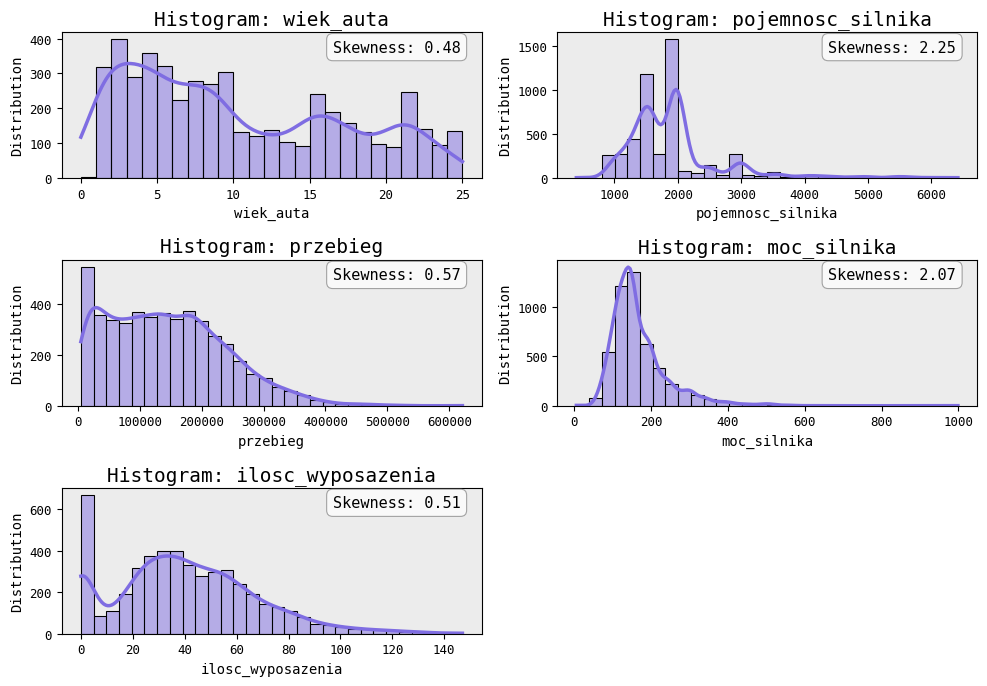

In [36]:
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(10, 7))
axes = axes.flatten()

for i, column_name in enumerate(numeric_columns):
    skewness_value = sp.stats.skew(vehicle_listings[column_name])

    if column_name == 'wiek_auta':
        min_val = vehicle_listings[column_name].min()
        max_val = vehicle_listings[column_name].max()
        bins = max_val - min_val
    else:
        bins = 30

    sns.histplot(data=vehicle_listings, x=column_name, bins=bins, kde=True, ax=axes[i])

    axes[i].text(
        0.95, 0.95, 
        f'Skewness: {skewness_value:.2f}',
        transform=axes[i].transAxes, 
        verticalalignment='top', 
        horizontalalignment='right',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='white', alpha=0.7, edgecolor='grey')
    )
    
    axes[i].set_title(f'Histogram: {column_name}')
    axes[i].set_ylabel('Distribution')
    
fig.delaxes(axes[-1])

plt.tight_layout()

The distributions of all numeric variables show right-skewness. This means that most observations are concentrated in the lower range of values.

For `ilosc_wyposazenia` and `wiek_auta`, the skewness is moderate. For `przebieg`, it is quite strong, while for `moc_silnika` and `pojemnosc_silnika`, the skewness is very strong. 


### **Bar Charts for the Basic Categorical Columns**

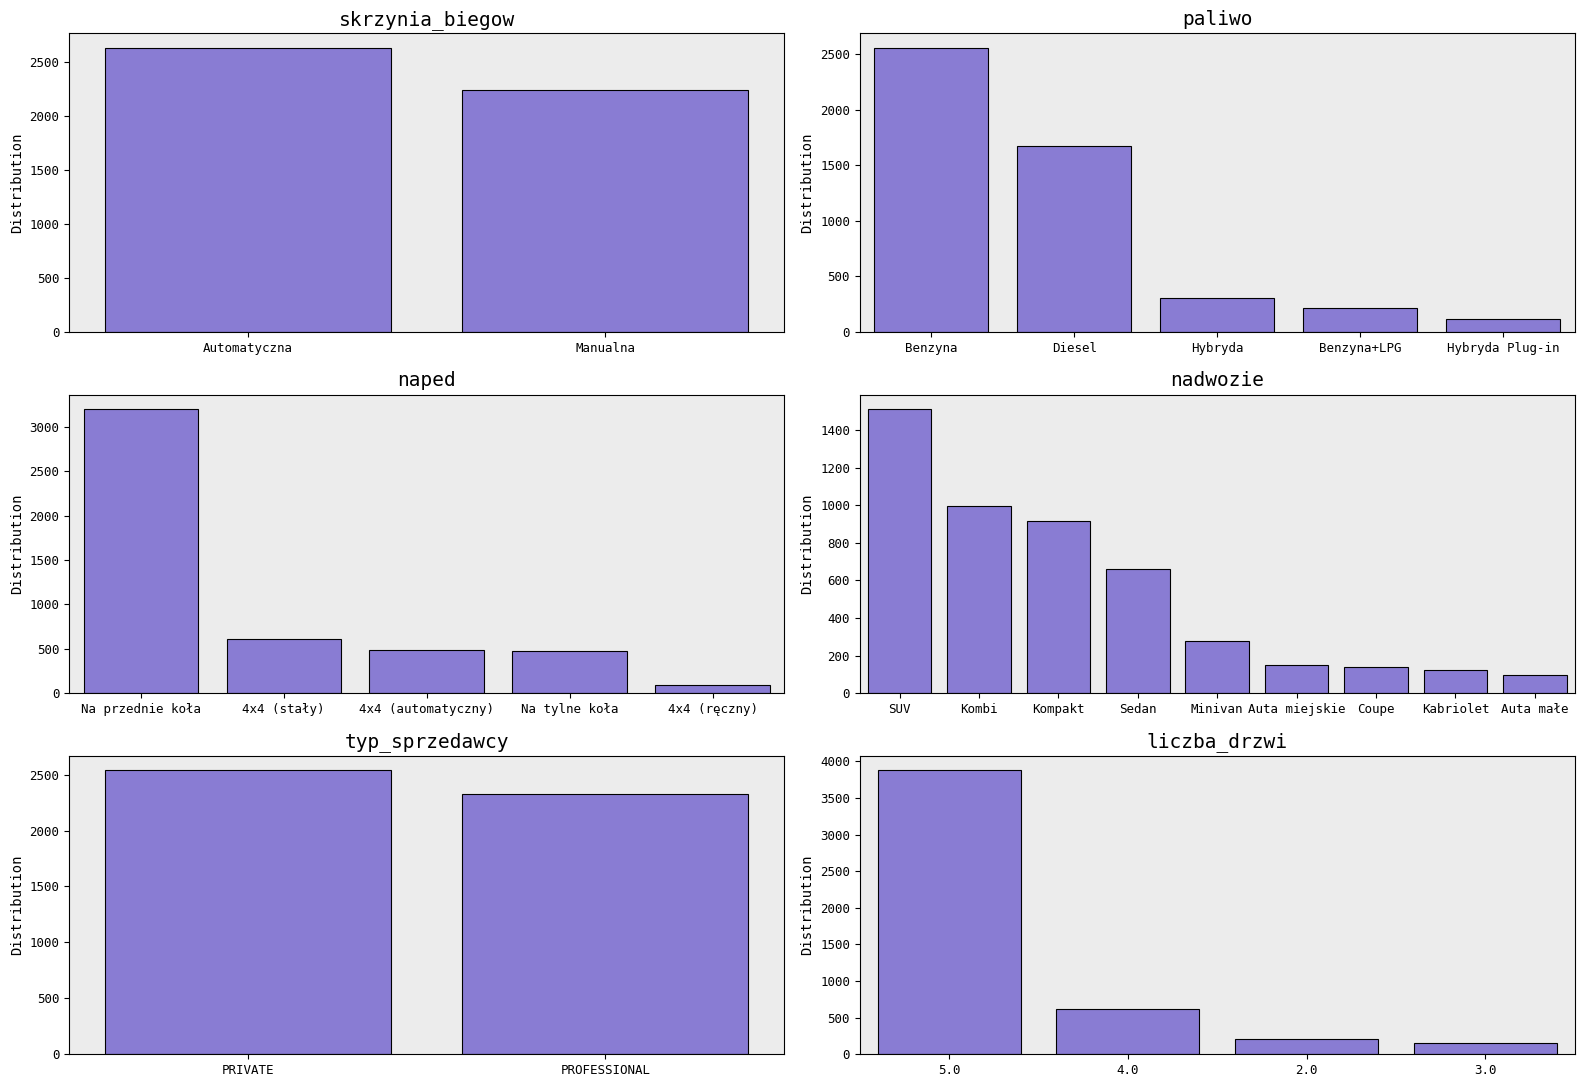

In [37]:
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(16, 11))
axes = axes.flatten()
categorical_columns_to_plot = base_categorical_columns.drop(['marka', 'wojewodztwo', 'kolor'])
for i, column_name in enumerate(categorical_columns_to_plot):

    if column_name == 'wiek_auta':
        min_val = vehicle_listings[column_name].min()
        max_val = vehicle_listings[column_name].max()
        bins = max_val - min_val
    else:
        bins = 30 

    sns.countplot(data=vehicle_listings, x=column_name, ax=axes[i], order=vehicle_listings[column_name].value_counts().index)
    
    axes[i].set_title(f'{column_name}')
    axes[i].set_ylabel('Distribution')
    axes[i].set_xlabel('')
    

plt.tight_layout()

The bar chart shows the frequency of each fuel type in the analyzed dataset.

For the `paliwo` variable, we see a clear dominance of traditional combustion engines. Vehicles with an electric powertrain are a clear minority.

For the `napęd` variable, front-wheel drive is the most common choice. It is the most popular solution because it is simple and easy to maintain.

For the `nadwozie` variable, SUVs dominate the car market, and the same is true in this dataset.

For the `typ sprzedawcy` variable, we see a small difference, with private sellers being slightly more common.

For the `skrzynia biegow` variable, the automatic transmission category is clearly more frequent.

For the `liczba drzwi` variable, most vehicles in the dataset are the classic five-door type.

### **Bar Charts for Equipment Categorical Columns**

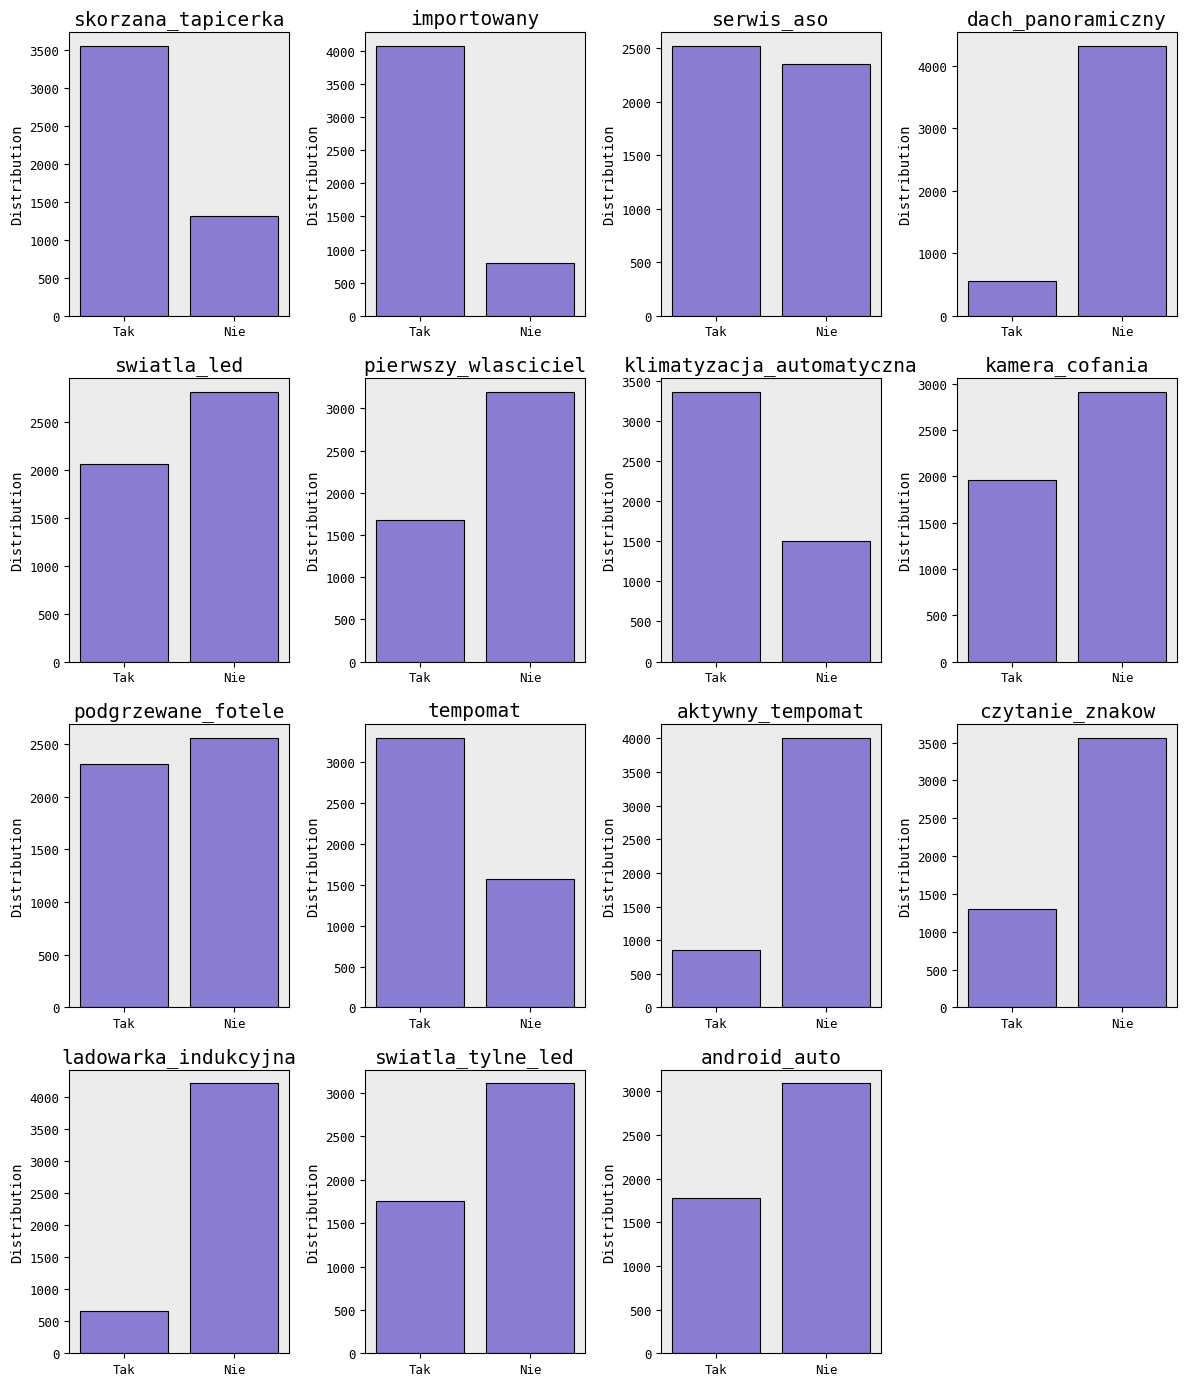

In [38]:
fig, axes = plt.subplots(nrows=4, ncols=4, figsize=(12, 14))
axes = axes.flatten()


for i, column_name in enumerate(equipment_categorical_columns):

    if column_name == 'wiek_auta':
        min_val = vehicle_listings[column_name].min()
        max_val = vehicle_listings[column_name].max()
        bins = max_val - min_val
    else:
        bins = 30 

    sns.countplot(data=vehicle_listings, x=column_name, ax=axes[i], order=["Tak", "Nie"])
    
    axes[i].set_title(f'{column_name}')
    axes[i].set_ylabel('Distribution')
    axes[i].set_xlabel('')
    
fig.delaxes(axes[-1])
plt.tight_layout()

### **Bar Chart for the Color Variable**

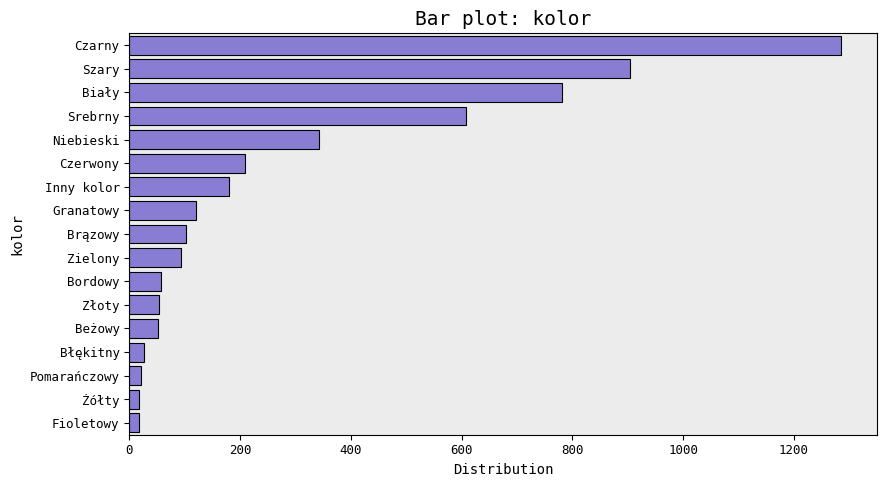

In [39]:
fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(9,5))

for i, column_name in enumerate(['kolor']):
    sns.countplot(data=vehicle_listings, y=column_name, ax=axes, order=vehicle_listings[column_name].value_counts().index, )
    
    axes.set_title(f'Bar plot: {column_name}')
    axes.set_xlabel('Distribution')

plt.tight_layout()

For the `kolor` variable, classic and muted colors are the most popular. However, the `Inny kolor` category represents the combined count of many rare colors, roughly 120 of them.

### **Bar Chart for the Voivodeship Column Compared with Population Size**

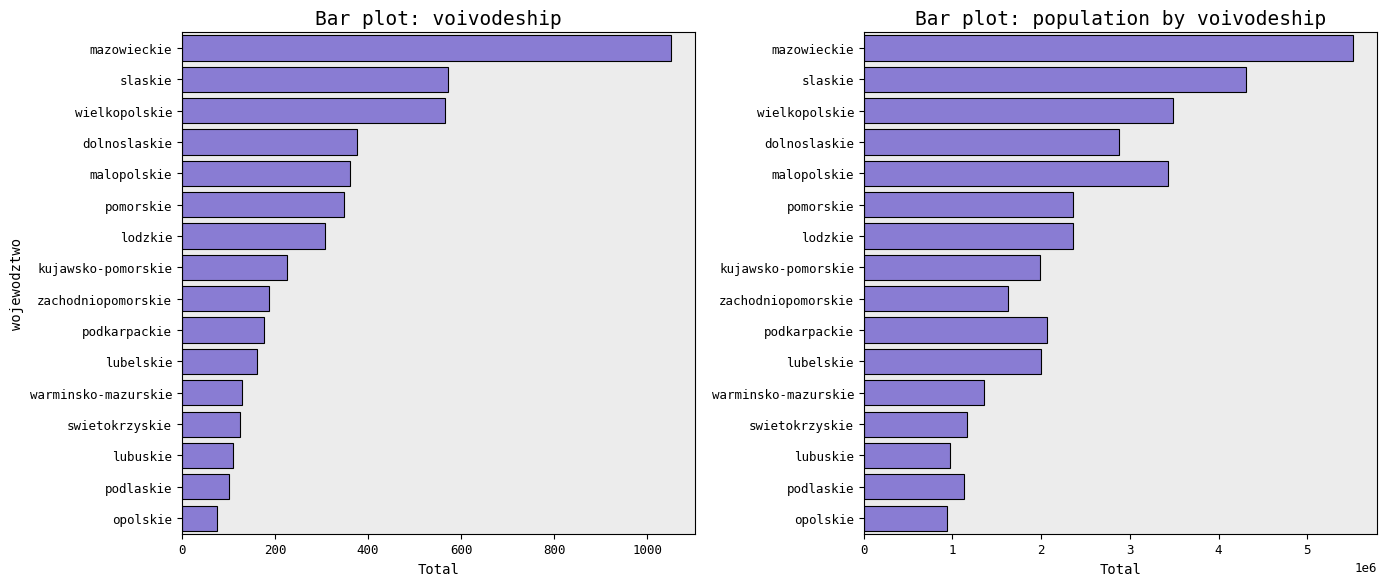

In [40]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14,6))
POPULATION_BY_VOIVODESHIP = {
    "mazowieckie": 5510618,
    "slaskie": 4305126,
    "wielkopolskie": 3484177,
    "malopolskie": 3429685,
    "dolnoslaskie": 2874496,
    "pomorskie": 2359956,
    "lodzkie": 2354135,
    "podkarpackie": 2067139,
    "lubelskie": 2003475,
    "kujawsko-pomorskie": 1990323,
    "zachodniopomorskie": 1626876,
    "warminsko-mazurskie": 1353374,
    "swietokrzyskie": 1163001,
    "podlaskie": 1135201,
    "lubuskie": 972140,
    "opolskie": 933349
}

sns.countplot(data=vehicle_listings, y='wojewodztwo', ax=axes[0], order=vehicle_listings['wojewodztwo'].value_counts().index)   
axes[0].set_title(f'Bar plot: voivodeship')
axes[0].set_xlabel('Total')

sns.barplot(data=pd.Series(POPULATION_BY_VOIVODESHIP), ax=axes[1], order=vehicle_listings['wojewodztwo'].value_counts().index, orient='h')
axes[1].set_title(f'Bar plot: population by voivodeship')
axes[1].set_xlabel('Total')


plt.tight_layout()

The number of vehicle listings in each voivodeship is correlated with the population size of that voivodeship.

### **Scatter Plot for Numeric Variables with Computed Correlation**

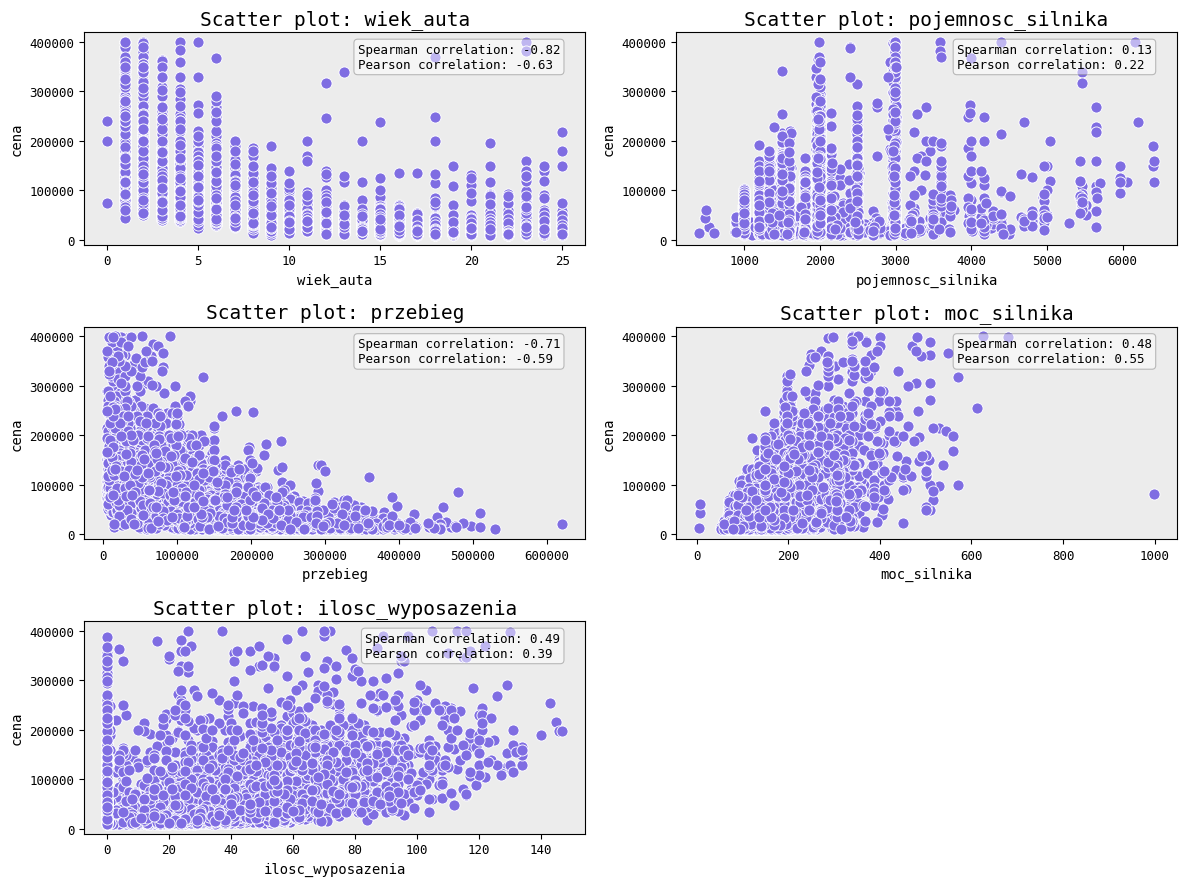

In [41]:
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(12,9))
axes = axes.flatten()
for i, column_name in enumerate(numeric_columns):

    sns.scatterplot(data=vehicle_listings, y='cena', x=column_name, ax=axes[i])
    
    axes[i].text(
        0.95, 0.95, 
        f'Spearman correlation: {vehicle_listings["cena"].corr(vehicle_listings[column_name], method="spearman"):.2f}\nPearson correlation: {vehicle_listings["cena"].corr(vehicle_listings[column_name], method="pearson"):.2f}',
        transform=axes[i].transAxes, 
        fontsize=9,
        verticalalignment='top', 
        multialignment='left',
        horizontalalignment='right',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.5, edgecolor='grey')
    )

    axes[i].set_title(f'Scatter plot: {column_name}')
    
fig.delaxes(axes[-1])
plt.tight_layout()

For the `wiek_auta` variable, the linear Pearson correlation is moderately negative. The non-linear Spearman correlation, also negative, is strong.

For the `pojemnosc_silnika` variable, both correlation coefficients are low, so engine displacement may not have a significant effect on price.

For the `przebieg` variable, both the Pearson and Spearman correlations show a moderately negative relationship. However, we can see that vehicles in the upper price range much more often have low mileage.

The `moc_silnika` variable has the strongest linear relationship with price. The relationship is positive: as engine power increases, price also increases.

### **Correlation Matrix (Heat Map) of Numeric Variables**

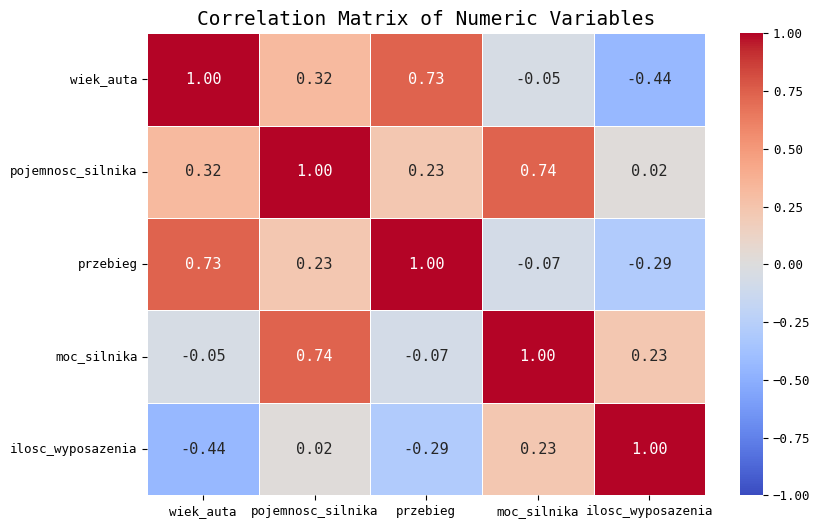

In [42]:
correlation_matrix = vehicle_listings[numeric_columns].corr()
sns.heatmap(
    correlation_matrix, 
    annot=True,       
    cmap='coolwarm',   
    fmt=".2f",        
    linewidths=0.7,   
    vmin=-1, vmax=1
)
plt.title('Correlation Matrix of Numeric Variables')
plt.show()

The correlation chart clearly shows two relationships between the explanatory variables:

`wiek_auta` - `przebieg`, with a correlation coefficient of 0.72. 

`pojemnosc_silnika` - `moc_silnika`, with a correlation coefficient of 0.74.

From a business perspective, these relationships are natural: as vehicles get older, they are used longer, which is reflected in their mileage. Looking at how combustion engines are built and how they work, we know that a larger displacement allows the engine to generate more power.

This phenomenon is called collinearity. It can potentially have negative effects, which may become visible later, during model building.

### **Price Density Plot by Fuel Type**

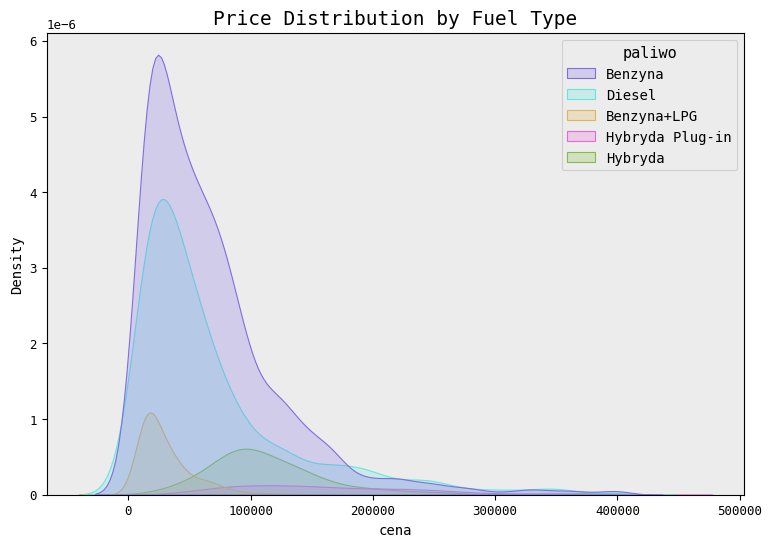

In [43]:
fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(9,6))
sns.kdeplot(data=vehicle_listings, x='cena', hue='paliwo', fill=True, ax=axes)
plt.title('Price Distribution by Fuel Type')
plt.show()

All the distributions show strong right-skewness. This means that in every category, the large majority of cars are concentrated in the lower price ranges.

`Benzyna` and `Diesel`, the distributions of these two segments are very similar in both shape and position.

`Hybryda`, based on the distribution, we can conclude that prices for vehicles with this powertrain are higher and more varied. The distribution is platykurtic. 

`Benzyna+LPG` is the cheapest segment of vehicles; cars in this segment above 100,000 PLN are very rare.





### **Box Plots for Basic Categorical Columns**

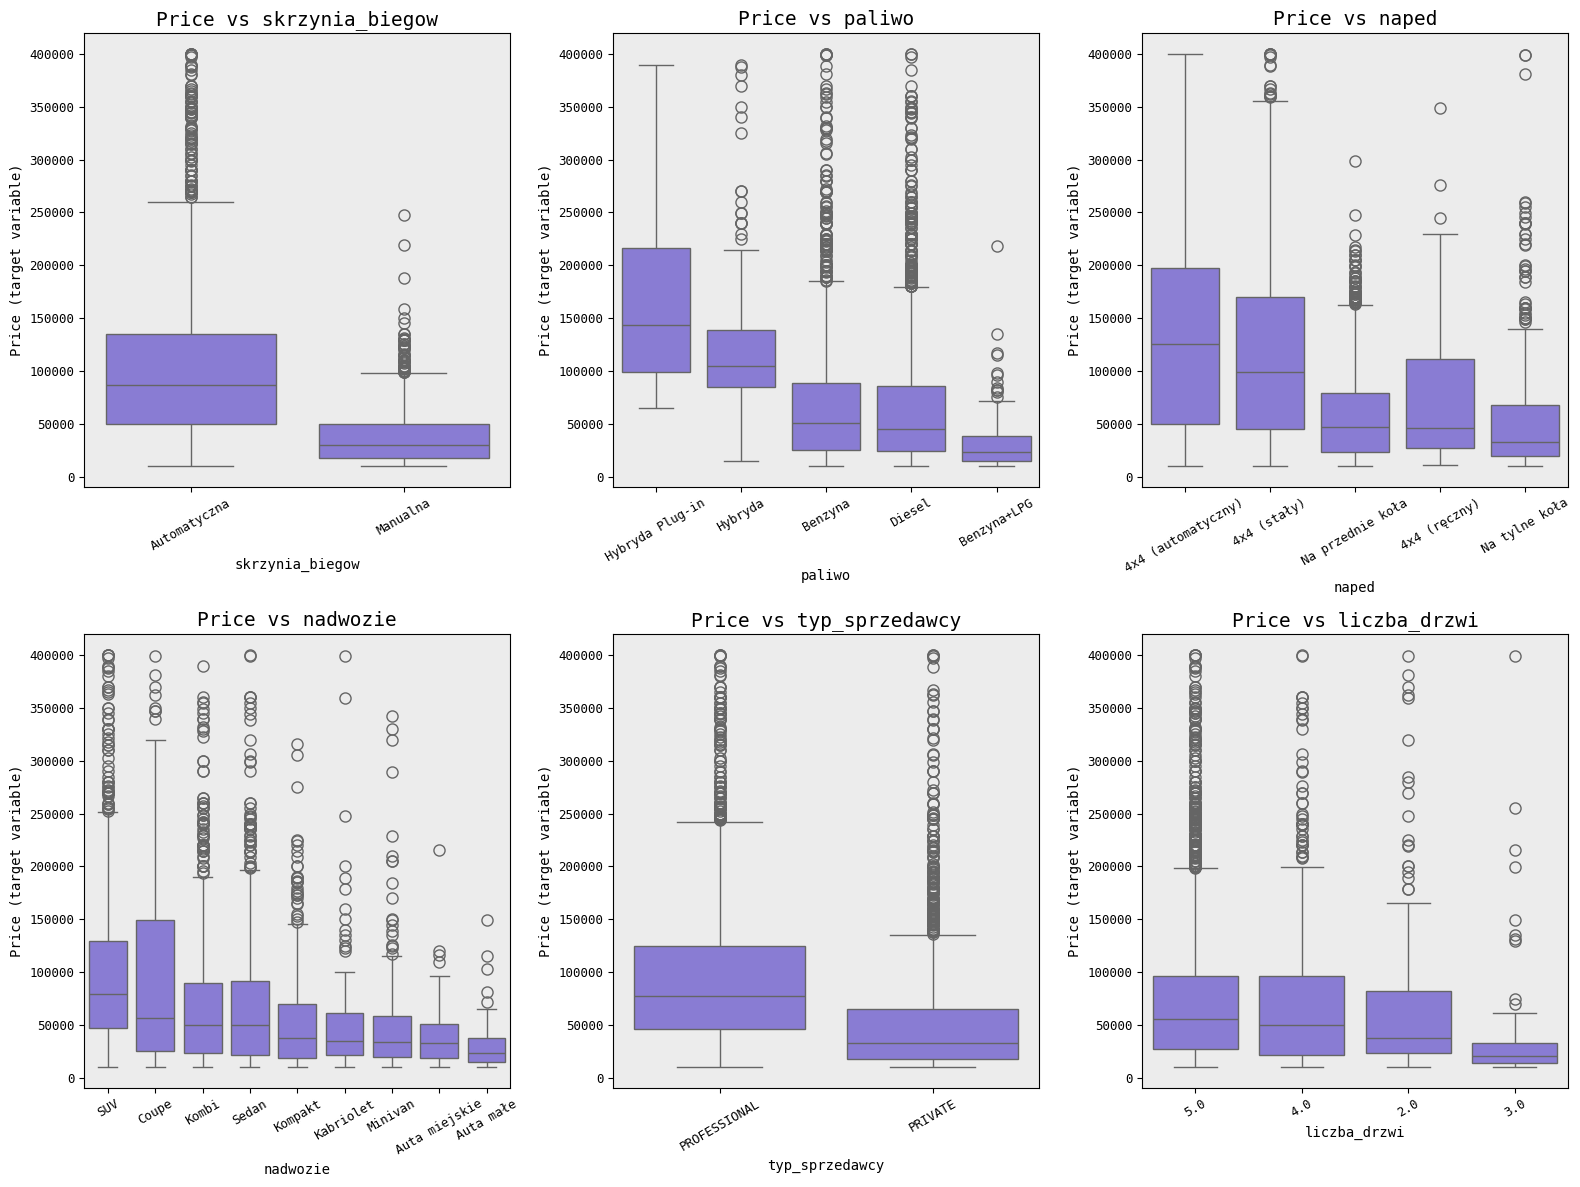

In [44]:
target_column = 'cena'
boxplot_categorical_columns = ["skrzynia_biegow", "naped", "nadwozie", "paliwo", "typ_sprzedawcy"]

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(16, 12))
axes = axes.flatten()

for i, column_name in enumerate(base_categorical_columns.drop(['marka', 'wojewodztwo', 'kolor'])):
    order = vehicle_listings.groupby(column_name)[target_column].median().sort_values(ascending=False).index

    sns.boxplot(data=vehicle_listings, x=column_name, y=target_column, ax=axes[i], order=order)
    
    axes[i].set_title(f'Price vs {column_name}')
    axes[i].set_xlabel(column_name)
    axes[i].set_ylabel('Price (target variable)')
    axes[i].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()



These box plots show prices broken down by category for each qualitative variable, letting us evaluate how price is distributed for each value.

`skrzynia_biegow`, the average vehicle with an automatic transmission is significantly more expensive than the average vehicle with a manual transmission. Prices for automatic vehicles are also more varied.

`paliwo`, electric vehicles have the highest median price and are also significantly more varied. Petrol vehicles have a slightly higher median than diesel vehicles. The cheapest cars run on `Benzyna+LPG`.

`napęd`, vehicles with 4x4 drive have the highest median regardless of their specific setup, while front-wheel-drive vehicles are generally the cheapest and show little variation.

`nadwozie`, coupes are the most expensive. This may be because this body type includes sports cars from premium brands. In general, price also decreases as the vehicle's size decreases.

`czy_uszkodzony`, in line with business intuition, damaged vehicles have significantly lower value.

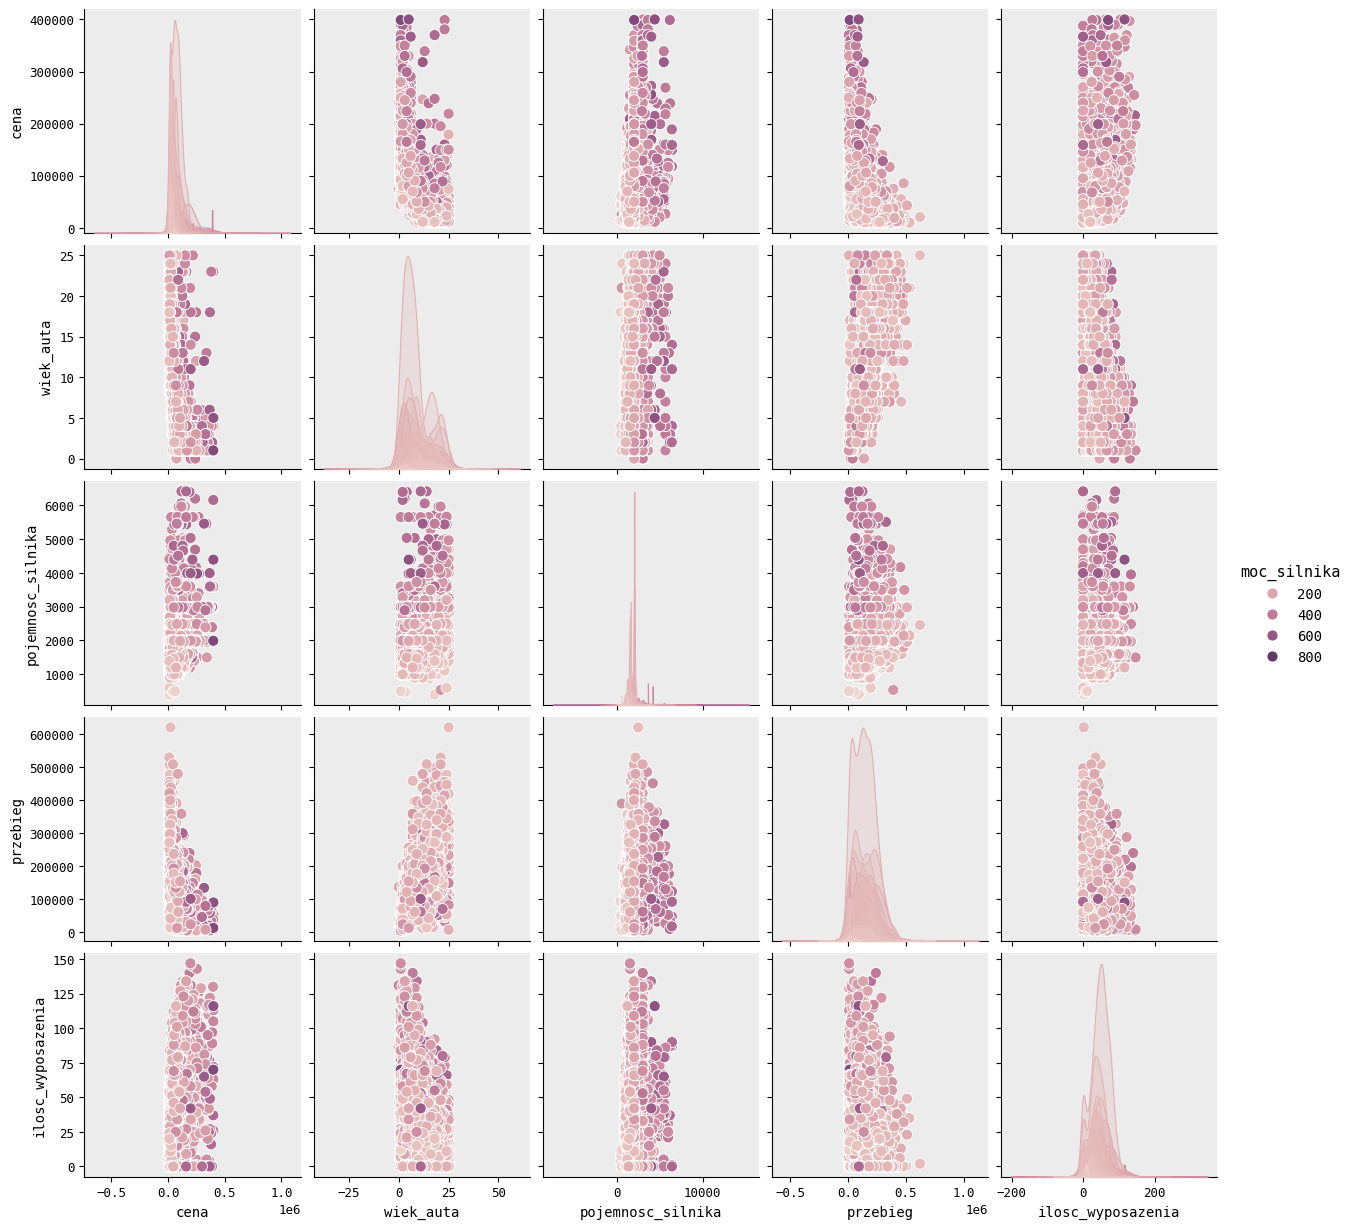

In [45]:
sns.pairplot(vehicle_listings, hue='moc_silnika')
plt.show()

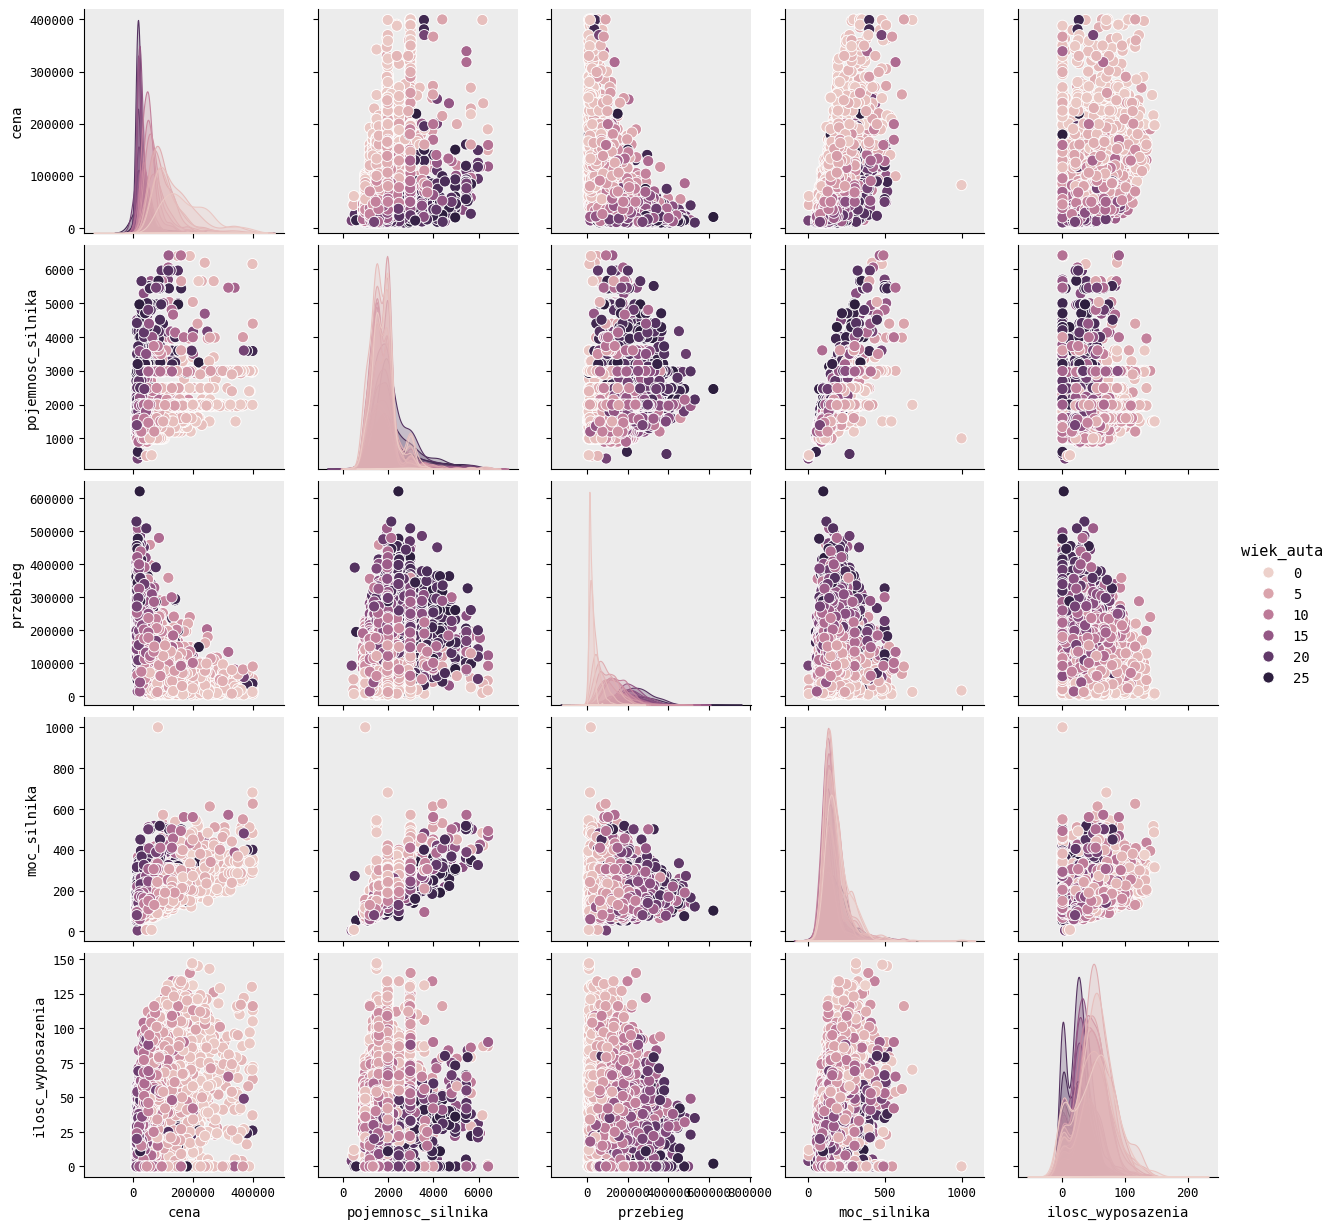

In [46]:
sns.pairplot(vehicle_listings, hue='wiek_auta')
plt.show()